# Análisis Temporal y Estacional del Dataset Hidrometeorológico de Sinaloa

**Proyecto:** Reconstrucción de Base de Datos Hidrometeorológica mediante Técnicas de Inteligencia Artificial  
**Laboratorio:** Geomática y Teledetección  
**Fuente de datos:** Archivos parquet — capa `interim/organized/estado=sin`

Este notebook documenta el análisis de las variaciones anuales, los patrones estacionales y el comportamiento de las variables climáticas a lo largo del ciclo hidrológico. Las variables analizadas son precipitación (PRECIP), evaporación (EVAP), temperatura máxima (TMAX) y temperatura mínima (TMIN), obtenidas de 168 estaciones climatológicas del estado de Sinaloa con registros diarios históricos.


## 1. Importación de librerías

In [1]:
from pathlib import Path
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_rows", 100)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Configuración de rutas

> Actualiza `PROJECT_ROOT` con la ruta local del proyecto antes de ejecutar.

In [2]:
PROJECT_ROOT = Path(r"/home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main")
DATA_DIR     = PROJECT_ROOT / "data" / "interim" / "organized" / "estado=sin"
INDEX_PATH   = DATA_DIR / "_index.csv"
FIGURES_DIR  = PROJECT_ROOT / "reports" / "figures" / "analisis_temporal"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("DATA_DIR     :", DATA_DIR)
print("INDEX_PATH   :", INDEX_PATH)
print("FIGURES_DIR  :", FIGURES_DIR)
print("Existe DATA_DIR  :", DATA_DIR.exists())
print("Existe INDEX_PATH:", INDEX_PATH.exists())

PROJECT_ROOT : /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main
DATA_DIR     : /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/data/interim/organized/estado=sin
INDEX_PATH   : /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/data/interim/organized/estado=sin/_index.csv
FIGURES_DIR  : /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/figures/analisis_temporal
Existe DATA_DIR  : True
Existe INDEX_PATH: True


## 3. Carga del conjunto de datos

Se carga el archivo `_index.csv`, que funciona como catálogo central del dataset organizado, y a partir de él se leen todos los archivos parquet con los registros diarios reales. Las rutas se normalizan para que el notebook funcione correctamente desde cualquier equipo.

In [3]:
index_df = pd.read_csv(INDEX_PATH)

def normalize_path(raw_path: str, root: Path) -> Path:
    p = Path(raw_path)
    if p.exists():
        return p
    parts = p.parts
    try:
        data_idx = next(i for i, part in enumerate(parts) if part == "data")
        return root / Path(*parts[data_idx:])
    except StopIteration:
        return p

index_df["path_parquet"] = index_df["path_parquet"].apply(lambda x: normalize_path(x, PROJECT_ROOT))
index_df["path_csv"]     = index_df["path_csv"].apply(lambda x: normalize_path(x, PROJECT_ROOT))
index_df = index_df.drop_duplicates(subset=["station", "year", "variable"]).reset_index(drop=True)

print(f"Particiones en el índice : {len(index_df)}")
print(f"Estaciones               : {index_df['station'].nunique()}")
print(f"Años                     : {index_df['year'].min()} – {index_df['year'].max()}")
print(f"Variables                : {sorted(index_df['variable'].unique())}")

Particiones en el índice : 19256
Estaciones               : 168
Años                     : 1908 – 2026
Variables                : ['evap', 'precip', 'tmax', 'tmin']


In [4]:
dfs = []
skipped = 0

for _, row in index_df.iterrows():
    parquet_path = Path(row["path_parquet"])
    if not parquet_path.exists():
        skipped += 1
        continue
    try:
        df_part = pd.read_parquet(parquet_path)
        df_part["date"]     = pd.to_datetime(df_part["date"], errors="coerce")
        df_part["value"]    = pd.to_numeric(df_part["value"], errors="coerce")
        df_part["station"]  = str(row["station"])
        df_part["year"]     = df_part["date"].dt.year
        df_part["month"]    = df_part["date"].dt.month
        df_part["variable"] = row["variable"]
        dfs.append(df_part)
    except Exception:
        skipped += 1

df = pd.concat(dfs, ignore_index=True)
df = df.dropna(subset=["date"]).sort_values(["station", "variable", "date"]).reset_index(drop=True)

print(f"Filas totales    : {len(df):,}")
print(f"Archivos omitidos: {skipped}")
print(f"Estaciones       : {df['station'].nunique()}")
print(f"Rango temporal   : {df['date'].min().date()} — {df['date'].max().date()}")

Filas totales    : 6,405,536
Archivos omitidos: 0
Estaciones       : 168
Rango temporal   : 1908-11-01 — 2026-02-28


In [5]:
VARIABLES = ["precip", "evap", "tmax", "tmin"]
LABELS = {
    "precip": "Precipitación (mm)",
    "evap":   "Evaporación (mm)",
    "tmax":   "Temperatura Máxima (°C)",
    "tmin":   "Temperatura Mínima (°C)",
}
COLORS = {"precip": "#2980b9", "evap": "#e67e22", "tmax": "#e74c3c", "tmin": "#8e44ad"}

---
## 4. Análisis de variaciones anuales

Para identificar tendencias de largo plazo, se calcula la media anual de cada variable promediando los registros de todas las estaciones activas en cada año. Solo se incluyen los años en los que al menos diez estaciones cuentan con datos válidos, para garantizar que la media sea representativa.

In [6]:
anual = (
    df.dropna(subset=["value"])
    .groupby(["year", "variable"])["value"]
    .mean()
    .reset_index()
    .rename(columns={"value": "media_anual"})
)

cobertura_anual = df.groupby(["year", "variable"])["station"].nunique().reset_index()
cobertura_anual.columns = ["year", "variable", "n_estaciones"]
anual = anual.merge(cobertura_anual, on=["year", "variable"])
anual = anual[anual["n_estaciones"] >= 10].copy()

print("Años con cobertura ≥ 10 estaciones por variable:")
print(anual.groupby("variable")["year"].agg(["min", "max", "count"]).to_string())

Años con cobertura ≥ 10 estaciones por variable:
           min   max  count
variable                   
evap      1953  2026     74
precip    1953  2026     74
tmax      1953  2026     74
tmin      1953  2026     74


### 4.1 Tendencia anual mediante regresión lineal

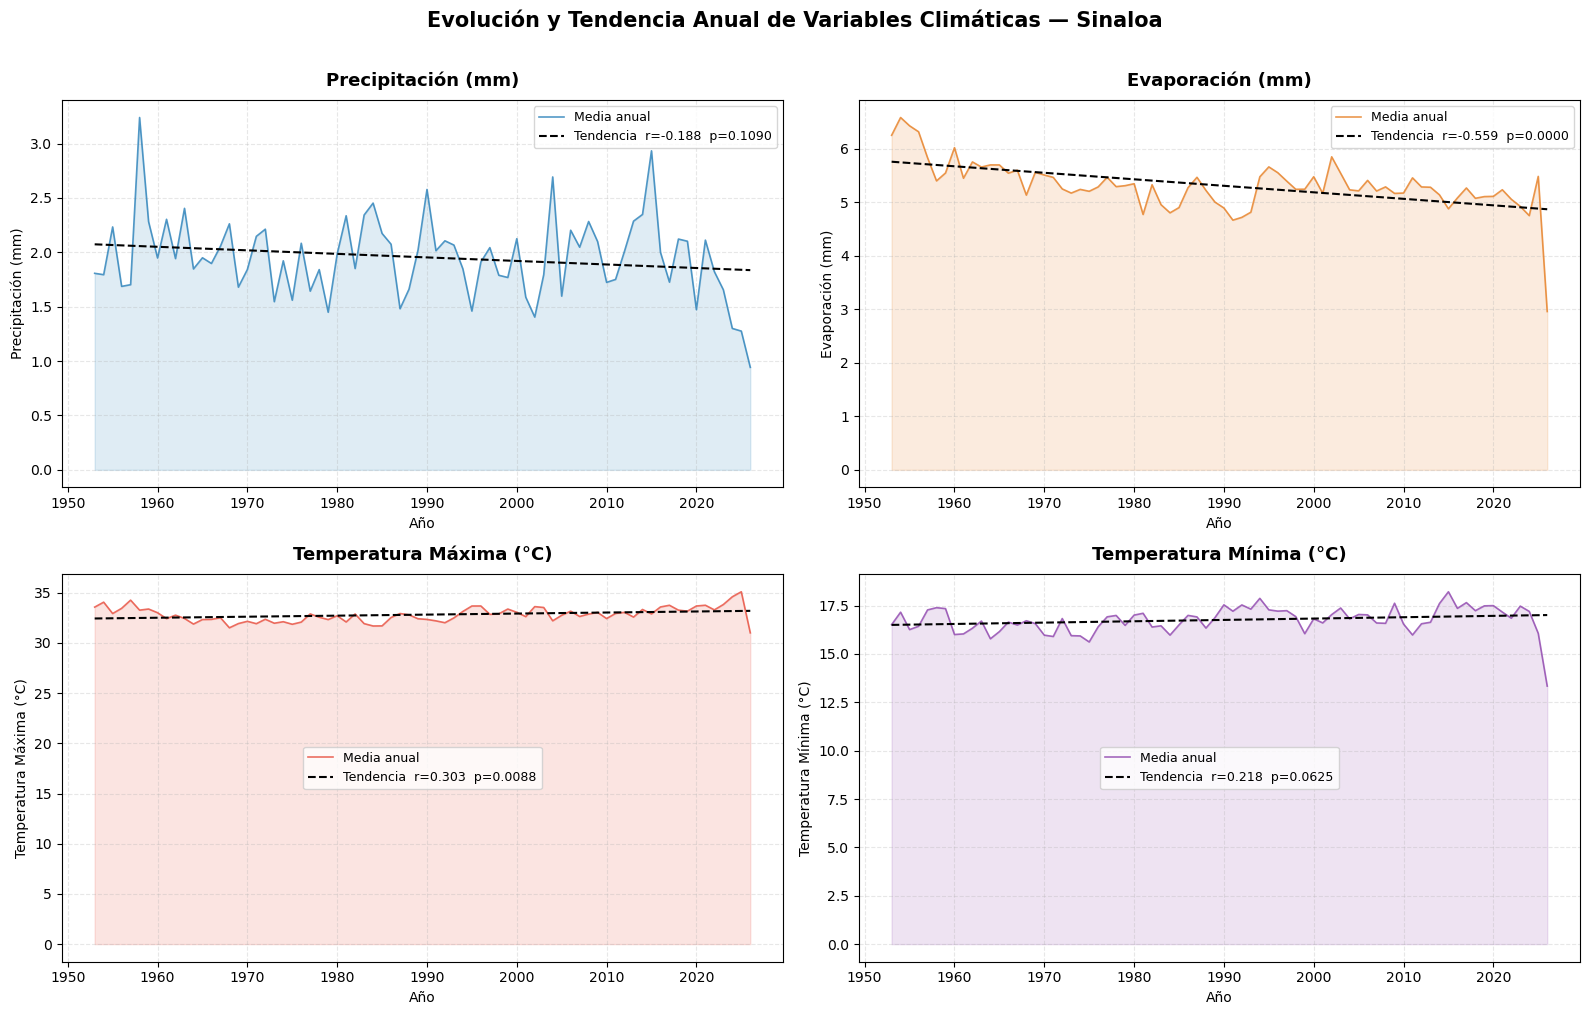

Figura guardada: tendencia_anual_variables.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

tendencias = []

for idx, var in enumerate(VARIABLES):
    ax = axes[idx]
    sub = anual[anual["variable"] == var].sort_values("year")
    if sub.empty:
        continue

    x = sub["year"].values
    y = sub["media_anual"].values

    slope, intercept, r, p, _ = stats.linregress(x, y)
    y_pred = slope * x + intercept

    ax.fill_between(x, y, alpha=0.15, color=COLORS[var])
    ax.plot(x, y, color=COLORS[var], linewidth=1.2, alpha=0.8, label="Media anual")
    ax.plot(x, y_pred, "--", color="black", linewidth=1.5,
            label=f"Tendencia  r={r:.3f}  p={p:.4f}")

    ax.set_title(LABELS[var], fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Año", fontsize=10)
    ax.set_ylabel(LABELS[var], fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.xaxis.set_major_locator(mticker.MultipleLocator(10))

    tendencias.append({
        "variable"      : var,
        "pendiente"     : round(slope, 5),
        "r"             : round(r, 4),
        "p_valor"       : round(p, 4),
        "tendencia"     : "ascendente" if slope > 0 else "descendente",
        "significativa" : "Sí" if p < 0.05 else "No",
        "año_min"       : int(x.min()),
        "año_max"       : int(x.max()),
    })

plt.suptitle("Evolución y Tendencia Anual de Variables Climáticas — Sinaloa",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "tendencia_anual_variables.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: tendencia_anual_variables.png")

In [8]:
tendencias_df = pd.DataFrame(tendencias)
print("Resumen de tendencias anuales:")
print(tendencias_df.to_string(index=False))

Resumen de tendencias anuales:
variable  pendiente       r  p_valor   tendencia significativa  año_min  año_max
  precip   -0.00325 -0.1878   0.1090 descendente            No     1953     2026
    evap   -0.01217 -0.5590   0.0000 descendente            Sí     1953     2026
    tmax    0.01041  0.3026   0.0088  ascendente            Sí     1953     2026
    tmin    0.00697  0.2176   0.0625  ascendente            No     1953     2026


### Interpretación

**Precipitación (PRECIP):** la variabilidad interanual es alta y está fuertemente ligada al fenómeno ENOS (El Niño–Oscilación del Sur). En el noroeste de México, los episodios de El Niño tienden a producir más lluvia en invierno y déficits durante el verano monzónico, mientras que La Niña genera el patrón opuesto. La pendiente de la regresión indica si existe una tendencia de cambio de largo plazo más allá de esta variabilidad natural.

**Evaporación (EVAP):** el alto porcentaje de faltantes estructurales (38.3%) introduce incertidumbre en la serie anual, especialmente en las primeras décadas. La tendencia es más representativa a partir de 1960, cuando la cobertura de estaciones mejora. Una pendiente positiva es coherente con el calentamiento regional observado.

**Temperatura máxima (TMAX) y temperatura mínima (TMIN):** son las series con mayor continuidad histórica y las más adecuadas para el análisis de tendencias. Una tendencia positiva con significancia estadística (p < 0.05) es consistente con el calentamiento superficial documentado en México durante el siglo XX. La pendiente en °C/año, multiplicada por el número de años del periodo, indica el cambio acumulado total.

Las tendencias significativas (p < 0.05) deben considerarse al diseñar los modelos de imputación, para evitar que los valores reconstruidos introduzcan sesgos temporales respecto a los datos observados.


---
## 5. Análisis de variaciones estacionales

El análisis estacional caracteriza el comportamiento intraanual de cada variable mediante el perfil mensual promedio, calculado sobre todos los años y estaciones disponibles. Se incluyen barras de error (±1 desviación estándar) para mostrar la variabilidad interanual de cada mes, y se identifican los meses de valor máximo y mínimo.

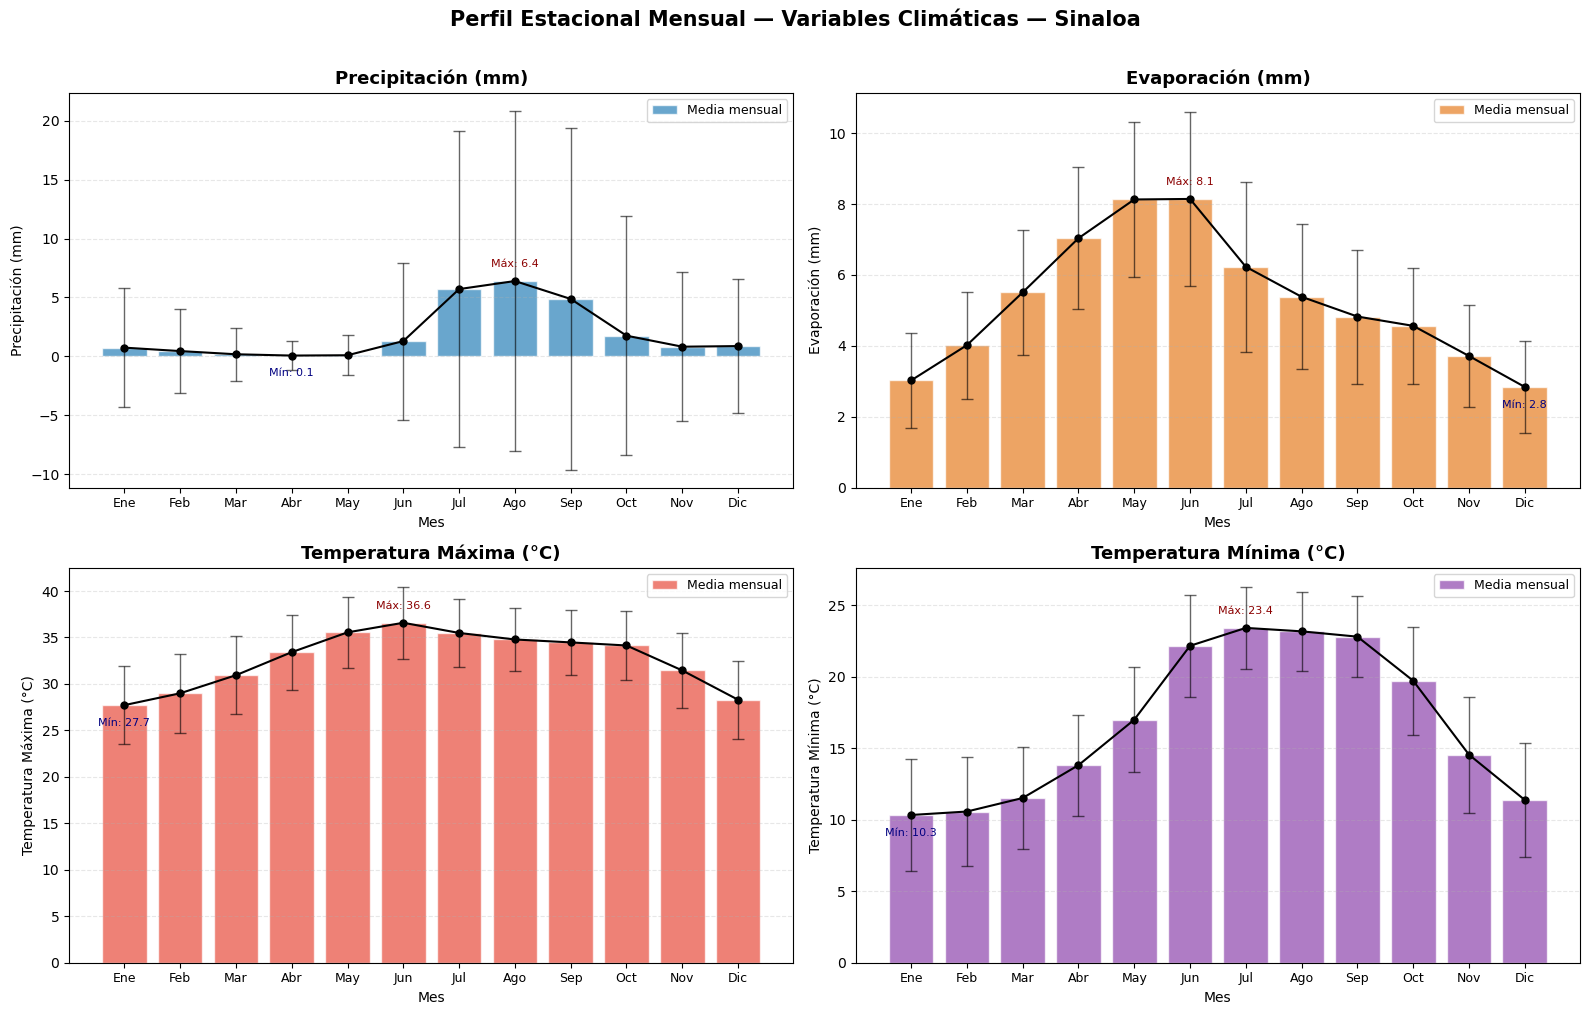

Figura guardada: perfil_estacional_mensual.png


In [9]:
MONTH_NAMES = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

estacional = (
    df.dropna(subset=["value"])
    .groupby(["month", "variable"])["value"]
    .agg(media="mean", std="std", mediana="median")
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, var in enumerate(VARIABLES):
    ax = axes[idx]
    sub = estacional[estacional["variable"] == var].sort_values("month")

    x = sub["month"].values
    y = sub["media"].values

    ax.bar(x, y, color=COLORS[var], alpha=0.7, edgecolor="white", label="Media mensual")
    ax.errorbar(x, y, yerr=sub["std"].values, fmt="none",
                color="black", capsize=4, linewidth=1, alpha=0.6)
    ax.plot(x, y, "o-", color="black", linewidth=1.5, markersize=5)

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_NAMES, fontsize=9)
    ax.set_title(LABELS[var], fontsize=13, fontweight="bold")
    ax.set_xlabel("Mes", fontsize=10)
    ax.set_ylabel(LABELS[var], fontsize=10)
    ax.grid(True, alpha=0.3, linestyle="--", axis="y")
    ax.legend(fontsize=9)

    i_max = y.argmax()
    i_min = y.argmin()
    ax.annotate(f"Máx: {y[i_max]:.1f}", xy=(x[i_max], y[i_max]),
                xytext=(0, 10), textcoords="offset points", ha="center", fontsize=8, color="darkred")
    ax.annotate(f"Mín: {y[i_min]:.1f}", xy=(x[i_min], y[i_min]),
                xytext=(0, -15), textcoords="offset points", ha="center", fontsize=8, color="navy")

plt.suptitle("Perfil Estacional Mensual — Variables Climáticas — Sinaloa",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "perfil_estacional_mensual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: perfil_estacional_mensual.png")

### 5.1 Amplitud estacional por variable

In [10]:
amplitud = []
for var in VARIABLES:
    sub = estacional[estacional["variable"] == var].sort_values("month")
    y = sub["media"].values
    mes_max = MONTH_NAMES[sub["month"].values[y.argmax()] - 1]
    mes_min = MONTH_NAMES[sub["month"].values[y.argmin()] - 1]
    amplitud.append({
        "variable"        : var,
        "media_anual"     : round(y.mean(), 3),
        "maximo_mensual"  : round(y.max(), 3),
        "mes_maximo"      : mes_max,
        "minimo_mensual"  : round(y.min(), 3),
        "mes_minimo"      : mes_min,
        "amplitud"        : round(y.max() - y.min(), 3),
    })

print("Amplitud estacional por variable:")
print(pd.DataFrame(amplitud).to_string(index=False))

Amplitud estacional por variable:
variable  media_anual  maximo_mensual mes_maximo  minimo_mensual mes_minimo  amplitud
  precip        1.942           6.396        Ago           0.073        Abr     6.322
    evap        5.285           8.143        Jun           2.842        Dic     5.301
    tmax       32.652          36.581        Jun          27.718        Ene     8.863
    tmin       16.697          23.407        Jul          10.328        Ene    13.079


### 5.2 Comparación del perfil estacional por décadas

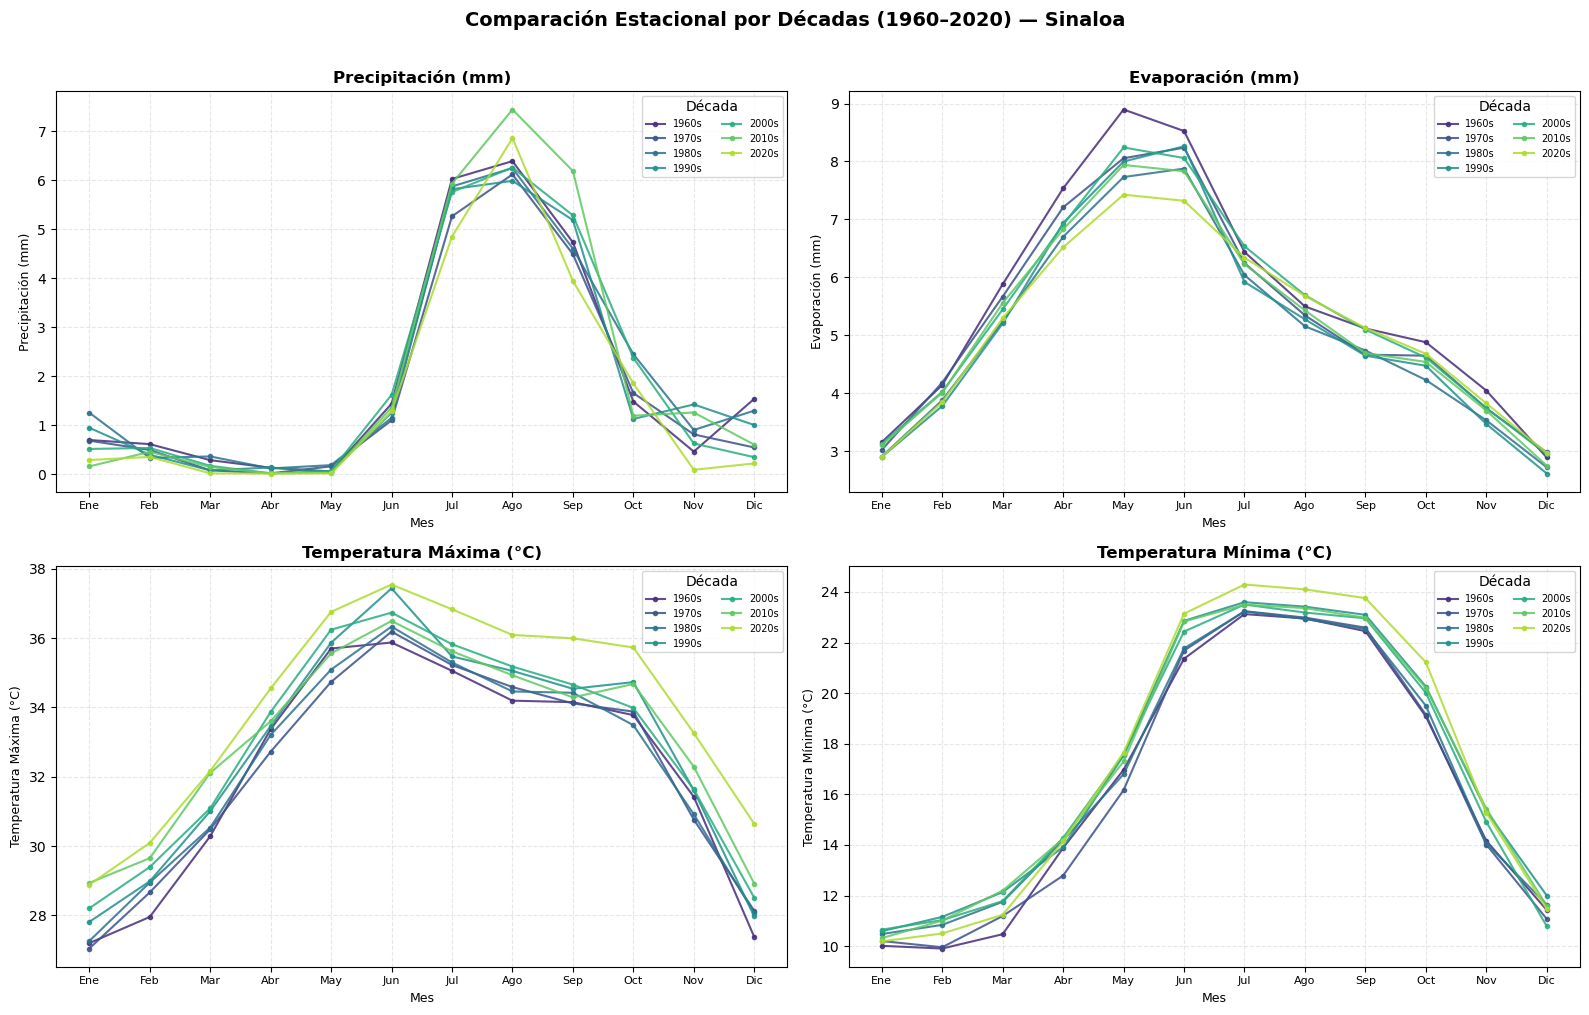

Figura guardada: estacional_por_decadas.png


In [11]:
df["decada"] = (df["year"] // 10) * 10

decadal = (
    df.dropna(subset=["value"])
    .groupby(["decada", "month", "variable"])["value"]
    .mean()
    .reset_index()
    .rename(columns={"value": "media"})
)

decadas_validas = [d for d in sorted(decadal["decada"].unique()) if d >= 1960]
palette = sns.color_palette("viridis", len(decadas_validas))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, var in enumerate(VARIABLES):
    ax = axes[idx]
    sub_var = decadal[(decadal["variable"] == var) & (decadal["decada"].isin(decadas_validas))]

    for i, dec in enumerate(decadas_validas):
        sub_dec = sub_var[sub_var["decada"] == dec].sort_values("month")
        if sub_dec.empty:
            continue
        ax.plot(sub_dec["month"], sub_dec["media"],
                color=palette[i], linewidth=1.5, marker="o", markersize=3,
                label=str(int(dec)) + "s", alpha=0.85)

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_NAMES, fontsize=8)
    ax.set_title(LABELS[var], fontsize=12, fontweight="bold")
    ax.set_xlabel("Mes", fontsize=9)
    ax.set_ylabel(LABELS[var], fontsize=9)
    ax.legend(title="Década", fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3, linestyle="--")

plt.suptitle("Comparación Estacional por Décadas (1960–2020) — Sinaloa",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "estacional_por_decadas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: estacional_por_decadas.png")

### Interpretación

El perfil estacional confirma que el clima de Sinaloa está gobernado por el Monzón Mexicano, sistema que determina cuándo y cuánto llueve en el noroeste del país.

**Precipitación (PRECIP):** es la variable con mayor estacionalidad. Las lluvias se concentran entre junio y octubre, con el máximo en julio o agosto. El período seco, de noviembre a mayo, registra precipitaciones cercanas a cero. Esta diferencia tan marcada entre meses es clave para el proceso de imputación: el valor esperado en agosto es muy distinto al de febrero, por lo que los modelos deben incorporar la componente estacional de forma explícita.

**Evaporación (EVAP):** los valores más altos se registran en los meses de mayor temperatura y radiación solar (mayo–julio). La amplitud estacional es moderada en comparación con la precipitación.

**Temperatura máxima (TMAX):** alcanza su máximo en mayo–junio, antes de que inicien las lluvias. Con la llegada del monzón, la mayor cobertura nubosa y la humedad producen un ligero descenso en julio y agosto respecto al pico de mayo. Este comportamiento es típico de zonas semiáridas con influencia monzónica.

**Temperatura mínima (TMIN):** sigue un ciclo similar al de TMAX pero con menor amplitud. Los valores más bajos ocurren en diciembre–enero y los más altos en mayo–junio.

La comparación por décadas permite ver si el patrón estacional ha cambiado con el tiempo. Desplazamientos en la fecha del máximo de precipitación o aumentos progresivos de temperatura en décadas recientes serían señales de variabilidad climática de largo plazo con implicaciones directas para el modelado.


---
## 6. Análisis por ciclo hidrológico

El ciclo hidrológico en Sinaloa comienza en octubre, cuando termina la temporada lluviosa y se inicia el período seco, y concluye en septiembre del año siguiente al final de la siguiente temporada de lluvias. Organizar los datos bajo este ciclo (Oct–Sep) permite representar el balance hídrico de la cuenca de forma continua y natural, sin partir artificialmente la temporada de lluvias como ocurre con el año calendario.

### 6.1 Definición del año hidrológico

In [12]:
# Año hidrológico: Oct=mes 1, Nov=2, ..., Sep=12
HYDRO_MONTH_ORDER  = [10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9]
HYDRO_MONTH_LABELS = ["Oct","Nov","Dic","Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep"]

month_to_hydro = {m: i+1 for i, m in enumerate(HYDRO_MONTH_ORDER)}
df["hydro_month"] = df["month"].map(month_to_hydro)

# Año hidrológico: oct-dic pertenecen al año siguiente hidrológico
df["hydro_year"] = df["year"].where(df["month"] < 10, df["year"] + 1)

print("Tabla de correspondencia mes calendario → mes hidrológico:")
print(pd.DataFrame({
    "mes_calendario" : HYDRO_MONTH_ORDER,
    "mes_hidrologico": range(1, 13),
    "etiqueta"       : HYDRO_MONTH_LABELS
}).to_string(index=False))

Tabla de correspondencia mes calendario → mes hidrológico:
 mes_calendario  mes_hidrologico etiqueta
             10                1      Oct
             11                2      Nov
             12                3      Dic
              1                4      Ene
              2                5      Feb
              3                6      Mar
              4                7      Abr
              5                8      May
              6                9      Jun
              7               10      Jul
              8               11      Ago
              9               12      Sep


### 6.2 Perfil de las variables a lo largo del ciclo hidrológico

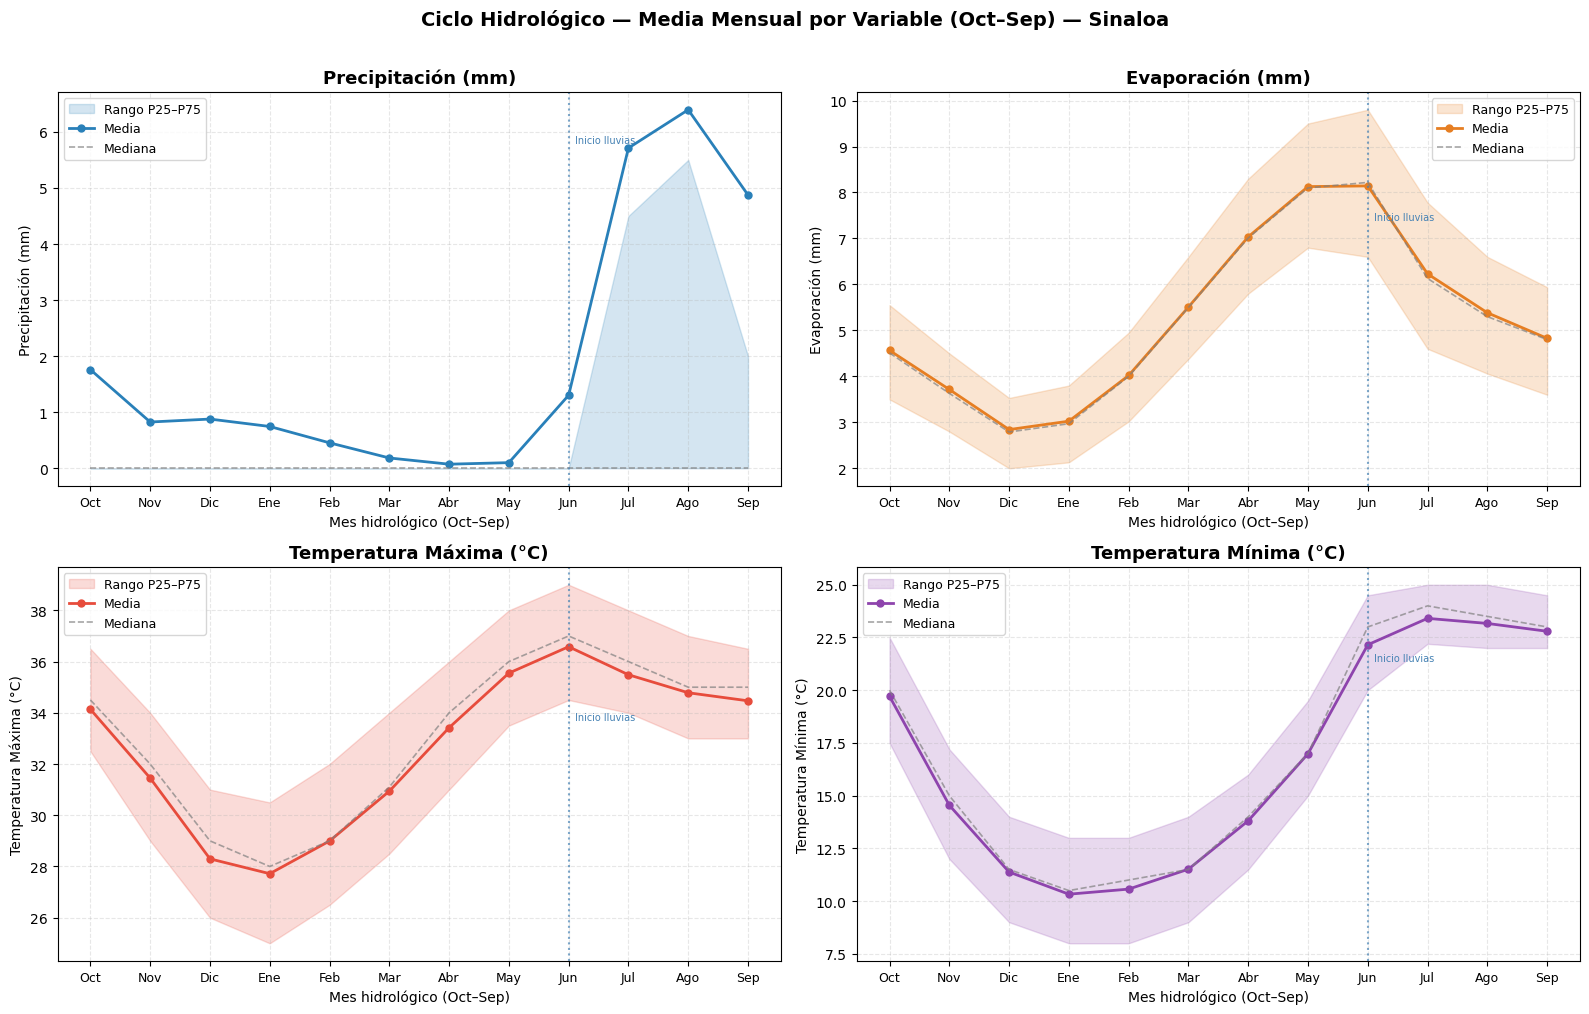

Figura guardada: ciclo_hidrologico_variables.png


In [14]:
estacional_hidro = (
    df.dropna(subset=["value"])
    .groupby(["hydro_month", "variable"])["value"]
    .agg(media="mean", std="std", mediana="median",
         p25=lambda x: x.quantile(0.25),
         p75=lambda x: x.quantile(0.75))
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, var in enumerate(VARIABLES):
    ax = axes[idx]
    sub = estacional_hidro[estacional_hidro["variable"] == var].sort_values("hydro_month")

    x   = sub["hydro_month"].values
    y   = sub["media"].values
    p25 = sub["p25"].values
    p75 = sub["p75"].values

    ax.fill_between(x, p25, p75, alpha=0.2, color=COLORS[var], label="Rango P25–P75")
    ax.plot(x, y, "o-", color=COLORS[var], linewidth=2, markersize=5, label="Media")
    ax.plot(x, sub["mediana"].values, "--", color="gray", linewidth=1.2, alpha=0.7, label="Mediana")

    # Separador temporada seca / lluviosa (mes hidrológico 9 = junio)
    ax.axvline(x=9, color="steelblue", linestyle=":", linewidth=1.5, alpha=0.7)
    ax.text(9.1, y.max() * 0.93, "Inicio lluvias", fontsize=7, color="steelblue", va="top")

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(HYDRO_MONTH_LABELS, fontsize=9)
    ax.set_title(LABELS[var], fontsize=13, fontweight="bold")
    ax.set_xlabel("Mes hidrológico (Oct–Sep)", fontsize=10)
    ax.set_ylabel(LABELS[var], fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, linestyle="--")

plt.suptitle("Ciclo Hidrológico — Media Mensual por Variable (Oct–Sep) — Sinaloa",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ciclo_hidrologico_variables.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: ciclo_hidrologico_variables.png")

### 6.3 Representación integrada del ciclo hidrológico

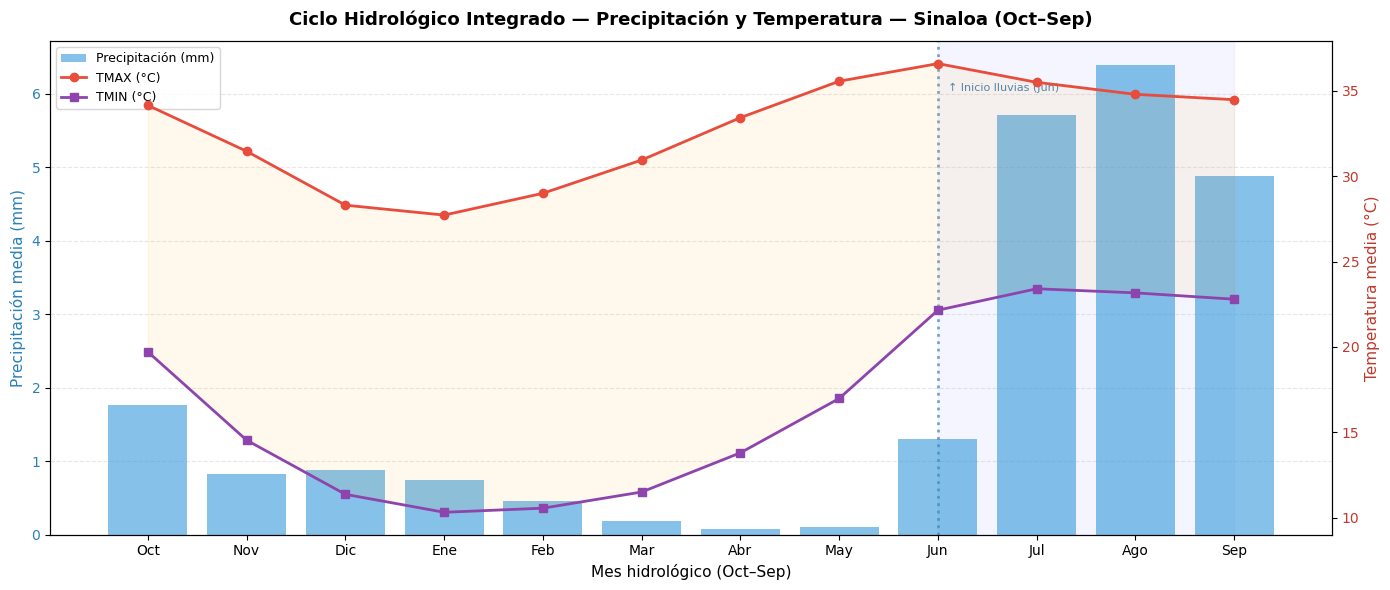

Figura guardada: ciclo_hidrologico_integrado.png


In [15]:
fig, ax1 = plt.subplots(figsize=(14, 6))

sub_p  = estacional_hidro[estacional_hidro["variable"] == "precip"].sort_values("hydro_month")
sub_tx = estacional_hidro[estacional_hidro["variable"] == "tmax"].sort_values("hydro_month")
sub_tn = estacional_hidro[estacional_hidro["variable"] == "tmin"].sort_values("hydro_month")

x = sub_p["hydro_month"].values

# Eje primario: precipitación (barras)
ax1.bar(x, sub_p["media"], color="#3498db", alpha=0.6, label="Precipitación (mm)", zorder=2)
ax1.set_xlabel("Mes hidrológico (Oct–Sep)", fontsize=11)
ax1.set_ylabel("Precipitación media (mm)", fontsize=11, color="#2980b9")
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(HYDRO_MONTH_LABELS, fontsize=10)
ax1.tick_params(axis="y", labelcolor="#2980b9")
ax1.grid(True, alpha=0.3, linestyle="--", axis="y")

# Eje secundario: temperatura
ax2 = ax1.twinx()
ax2.plot(x, sub_tx["media"], "o-", color="#e74c3c", linewidth=2, markersize=6,
         label="TMAX (°C)", zorder=3)
ax2.plot(x, sub_tn["media"], "s-", color="#8e44ad", linewidth=2, markersize=6,
         label="TMIN (°C)", zorder=3)
ax2.fill_between(x, sub_tn["media"], sub_tx["media"], alpha=0.07, color="orange")
ax2.set_ylabel("Temperatura media (°C)", fontsize=11, color="#c0392b")
ax2.tick_params(axis="y", labelcolor="#c0392b")

# Separador temporada seca / lluviosa
ax1.axvline(x=9, color="steelblue", linestyle=":", linewidth=2, alpha=0.7)
ax1.text(9.1, ax1.get_ylim()[1] * 0.90,
         "↑ Inicio lluvias (Jun)", fontsize=8, color="steelblue")
ax1.axvspan(9, 12, alpha=0.04, color="blue")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.title("Ciclo Hidrológico Integrado — Precipitación y Temperatura — Sinaloa (Oct–Sep)",
          fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ciclo_hidrologico_integrado.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: ciclo_hidrologico_integrado.png")

### 6.4 Evolución decadal del ciclo hidrológico

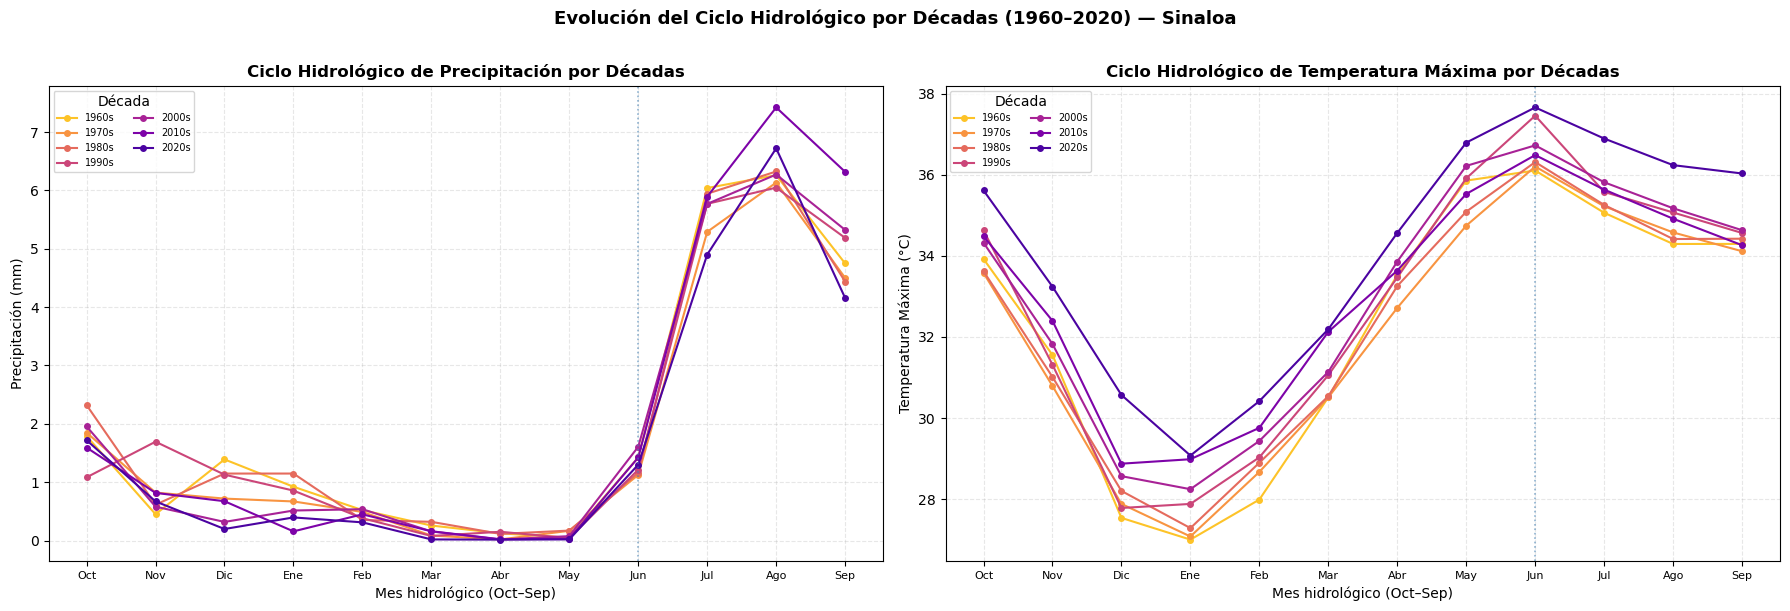

Figura guardada: ciclo_hidrologico_decadal.png


In [16]:
df["decada"] = (df["year"] // 10) * 10

hidro_decadal = (
    df.dropna(subset=["value"])
    .groupby(["hydro_year", "hydro_month", "variable"])["value"]
    .mean()
    .reset_index()
)
hidro_decadal["decada"] = (hidro_decadal["hydro_year"] // 10) * 10
hidro_decadal_agg = (
    hidro_decadal[hidro_decadal["decada"] >= 1960]
    .groupby(["decada", "hydro_month", "variable"])["value"]
    .mean()
    .reset_index()
)

decadas_hidro = sorted(hidro_decadal_agg["decada"].unique())
palette_d = sns.color_palette("plasma_r", len(decadas_hidro))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

for i, dec in enumerate(decadas_hidro):
    sub_d = hidro_decadal_agg[hidro_decadal_agg["decada"] == dec]

    sp = sub_d[sub_d["variable"] == "precip"].sort_values("hydro_month")
    if not sp.empty:
        ax1.plot(sp["hydro_month"], sp["value"], "o-", color=palette_d[i],
                 linewidth=1.5, markersize=4, label=f"{int(dec)}s")

    st = sub_d[sub_d["variable"] == "tmax"].sort_values("hydro_month")
    if not st.empty:
        ax2.plot(st["hydro_month"], st["value"], "o-", color=palette_d[i],
                 linewidth=1.5, markersize=4, label=f"{int(dec)}s")

for ax, var_label in [(ax1, "Precipitación (mm)"), (ax2, "Temperatura Máxima (°C)")]:
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(HYDRO_MONTH_LABELS, fontsize=8)
    ax.set_xlabel("Mes hidrológico (Oct–Sep)", fontsize=10)
    ax.set_ylabel(var_label, fontsize=10)
    ax.legend(title="Década", fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.axvline(x=9, color="steelblue", linestyle=":", linewidth=1.2, alpha=0.6)

ax1.set_title("Ciclo Hidrológico de Precipitación por Décadas", fontsize=12, fontweight="bold")
ax2.set_title("Ciclo Hidrológico de Temperatura Máxima por Décadas", fontsize=12, fontweight="bold")

plt.suptitle("Evolución del Ciclo Hidrológico por Décadas (1960–2020) — Sinaloa",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ciclo_hidrologico_decadal.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: ciclo_hidrologico_decadal.png")

### Interpretación

**Perfil por variable con rango intercuartílico:** la banda sombreada entre los percentiles 25 y 75 (P25–P75) muestra cuánto varían los valores de un año a otro en cada mes del ciclo. Los meses con mayor amplitud de esta banda, generalmente julio y agosto en precipitación, son los de mayor variabilidad histórica y los más difíciles de imputar. La diferencia entre la media y la mediana en los meses lluviosos refleja la influencia de eventos de precipitación intensa que elevan el promedio por encima del valor más frecuente.

**Representación integrada precipitación–temperatura:** la gráfica de doble eje permite ver al mismo tiempo el ciclo de lluvias y el ciclo térmico. Se observa claramente el desfase entre el máximo de temperatura (mayo–junio) y el máximo de precipitación (julio–agosto), que es una característica definitoria del Monzón Mexicano. La banda entre TMAX y TMIN representa la amplitud térmica diaria media de cada mes.

**Evolución decadal:** comparar los perfiles de distintas décadas permite identificar si el régimen hidrológico ha cambiado a lo largo del tiempo. Aumentos en la temperatura máxima durante los meses más cálidos, o cambios en la intensidad del pico lluvioso de julio–agosto entre las décadas de 1960 y 2020, son indicadores de variabilidad climática de largo plazo útiles para definir el período de referencia del modelado.


---
## 7. Comparación entre temporada seca y temporada lluviosa

Los registros se dividen en dos períodos: la temporada lluviosa (junio–septiembre, meses hidrológicos 9 a 12) y la temporada seca (octubre–mayo, meses hidrológicos 1 a 8). Para cada período y variable se calculan los principales descriptores de la distribución, que sirven como referencia para evaluar si los valores imputados son físicamente razonables.

In [17]:
df["temporada"] = df["hydro_month"].apply(
    lambda m: "Lluviosa (Jun–Sep)" if m >= 9 else "Seca (Oct–May)"
)

temporada_stats = (
    df.dropna(subset=["value"])
    .groupby(["variable", "temporada"])["value"]
    .agg(
        n      = "count",
        media  = "mean",
        mediana= "median",
        std    = "std",
        p10    = lambda x: x.quantile(0.10),
        p90    = lambda x: x.quantile(0.90),
        minimo = "min",
        maximo = "max",
    )
    .round(3)
    .reset_index()
)

for var in VARIABLES:
    print(f"\n{'='*65}")
    print(f"  {var.upper()} — {LABELS[var]}")
    print(f"{'='*65}")
    sub = temporada_stats[temporada_stats["variable"] == var].drop(columns="variable")
    print(sub.to_string(index=False))


  PRECIP — Precipitación (mm)
         temporada       n  media  mediana    std  p10  p90  minimo  maximo
Lluviosa (Jun–Sep)  533131  4.597      0.0 12.843  0.0 15.0     0.0   390.5
    Seca (Oct–May) 1057430  0.630      0.0  5.311  0.0  0.0     0.0   335.0

  EVAP — Evaporación (mm)
         temporada      n  media  mediana   std  p10  p90  minimo  maximo
Lluviosa (Jun–Sep) 327879  6.148      5.9 2.543 3.06  9.6    0.01   24.95
    Seca (Oct–May) 659865  4.849      4.4 2.444 2.05  8.3    0.01   22.56

  TMAX — Temperatura Máxima (°C)
         temporada      n  media  mediana   std  p10  p90  minimo  maximo
Lluviosa (Jun–Sep) 497942 35.329     35.5 3.712 31.0 39.9    13.0    52.0
    Seca (Oct–May) 990354 31.309     32.0 4.869 25.0 37.0     5.0    55.0

  TMIN — Temperatura Mínima (°C)
         temporada      n  media  mediana   std  p10  p90  minimo  maximo
Lluviosa (Jun–Sep) 497942 22.887     23.5 3.069 19.0 26.0     0.0    37.0
    Seca (Oct–May) 990354 13.606     13.5 4.935  7.5 2

### Interpretación

**Precipitación (PRECIP):** el contraste entre temporadas es el más marcado de las cuatro variables. La media de la temporada lluviosa supera ampliamente a la de la temporada seca, y la amplitud del intervalo P10–P90 durante el período húmedo refleja la alta variabilidad asociada a los eventos convectivos del monzón. Los valores por temporada son el marco de referencia para verificar que las imputaciones sean coherentes con el régimen pluviométrico histórico de cada período del año.

**Temperatura máxima (TMAX) y temperatura mínima (TMIN):** la diferencia entre temporadas es clara pero de menor magnitud que en precipitación. Los valores más altos se dan en primavera–verano y los más bajos en otoño–invierno. La amplitud del intervalo P10–P90 es similar entre temporadas, lo que indica una distribución relativamente simétrica.

**Evaporación (EVAP):** los valores más altos corresponden a la temporada más cálida, en línea con la mayor demanda evaporativa. Dado el alto porcentaje de faltantes en esta variable, los descriptores por temporada son especialmente importantes como criterios de validación para las imputaciones generadas.


---
## 8. Consolidado de hallazgos

In [18]:
hallazgos = pd.DataFrame({
    "componente": [
        "Variaciones anuales", "Variaciones anuales", "Variaciones anuales",
        "Variaciones estacionales", "Variaciones estacionales", "Variaciones estacionales",
        "Ciclo hidrológico", "Ciclo hidrológico", "Ciclo hidrológico",
    ],
    "hallazgo": [
        "Se calcularon series de medias anuales para las 4 variables sobre el periodo histórico disponible.",
        "Se aplicó regresión lineal para cuantificar tendencia, r de Pearson y p-valor por variable.",
        "La variabilidad interanual en PRECIP está asociada al ciclo ENSO; TMAX y TMIN muestran tendencias de calentamiento.",
        "PRECIP presenta estacionalidad extrema: lluvias concentradas en jun–sep bajo el ciclo monzónico.",
        "TMAX alcanza su máximo en mayo–junio, antes del inicio de las lluvias (desfase monzónico).",
        "La comparación por décadas permite detectar cambios en el patrón estacional a lo largo del siglo XX.",
        "El año hidrológico se definió de octubre a septiembre, coherente con el ciclo de cuenca sinaloense.",
        "La gráfica integrada muestra el desfase entre pico térmico (may–jun) y pico lluvioso (jul–ago).",
        "Los meses con mayor rango P25–P75 (jul–ago en precip) son los de mayor variabilidad y mayor reto para imputación.",
    ]
})
print(hallazgos.to_string(index=False))

              componente                                                                                                            hallazgo
     Variaciones anuales                  Se calcularon series de medias anuales para las 4 variables sobre el periodo histórico disponible.
     Variaciones anuales                         Se aplicó regresión lineal para cuantificar tendencia, r de Pearson y p-valor por variable.
     Variaciones anuales La variabilidad interanual en PRECIP está asociada al ciclo ENSO; TMAX y TMIN muestran tendencias de calentamiento.
Variaciones estacionales                    PRECIP presenta estacionalidad extrema: lluvias concentradas en jun–sep bajo el ciclo monzónico.
Variaciones estacionales                          TMAX alcanza su máximo en mayo–junio, antes del inicio de las lluvias (desfase monzónico).
Variaciones estacionales                La comparación por décadas permite detectar cambios en el patrón estacional a lo largo del siglo XX.
       Ciclo 

## 9. Conclusiones

El análisis temporal y estacional del dataset hidrometeorológico de Sinaloa permitió caracterizar el comportamiento de las cuatro variables climáticas en tres escalas temporales: tendencias de largo plazo, ciclo estacional intraanual y ciclo hidrológico regional.

**Variaciones anuales:** la precipitación muestra alta variabilidad interanual ligada al fenómeno ENOS, mientras que las variables de temperatura exhiben tendencias de calentamiento progresivo consistentes con el registro histórico regional. Las tendencias estadísticamente significativas (p < 0.05) deben incorporarse en los modelos de imputación para preservar la coherencia temporal de los valores reconstruidos.

**Variaciones estacionales:** el perfil mensual confirma el régimen monzónico de Sinaloa, con una estacionalidad muy pronunciada en precipitación y ciclos anuales bien definidos en temperatura y evaporación. Estos patrones deben representarse explícitamente en los modelos para garantizar que los valores imputados sean físicamente coherentes con el mes del año en que se producen. La comparación por décadas no muestra cambios abruptos en el patrón estacional, aunque se observan variaciones graduales en temperatura en los períodos más recientes.

**Ciclo hidrológico:** la representación en ciclo Oct–Sep documenta de forma natural el balance hídrico de la cuenca. La gráfica integrada evidencia el desfase entre el máximo térmico de primavera y el máximo lluvioso del verano monzónico. La variabilidad interanual expresada mediante el rango intercuartílico identifica los meses de mayor incertidumbre, orientando la definición de criterios de validación específicos para el proceso de imputación.

En conjunto, los resultados respaldan la necesidad de incluir variables temporales derivadas —mes del ciclo hidrológico, índices de estacionalidad— como covariables en los modelos de imputación, para capturar tanto la componente estacional como la tendencia de largo plazo sin introducir sesgos en la base de datos reconstruida.


## 10. Entregable

Este notebook documenta el análisis temporal y estacional del dataset hidrometeorológico de Sinaloa. Los productos generados son los siguientes:

**Variaciones anuales:**
- Series de medias anuales para PRECIP, EVAP, TMAX y TMIN, calculadas sobre años con cobertura mínima de diez estaciones
- Regresión lineal con pendiente, coeficiente de correlación de Pearson y valor p por variable
- Figura: `tendencia_anual_variables.png`

**Variaciones estacionales:**
- Perfil estacional mensual con media, mediana e intervalo de dispersión (±desviación estándar)
- Tabla de amplitud estacional con mes de máximo y mínimo por variable
- Comparación de perfiles estacionales por décadas (1960–2020)
- Figuras: `perfil_estacional_mensual.png`, `estacional_por_decadas.png`

**Ciclo hidrológico:**
- Definición del año hidrológico Oct–Sep con asignación de mes hidrológico a cada registro
- Perfil de las variables a lo largo del ciclo hidrológico con rango intercuartílico (P25–P75)
- Representación integrada precipitación–temperatura con eje secundario y delimitación de temporadas
- Evolución decadal del ciclo hidrológico (1960–2020)
- Figuras: `ciclo_hidrologico_variables.png`, `ciclo_hidrologico_integrado.png`, `ciclo_hidrologico_decadal.png`

**Comparación por temporada:**
- Descriptores estadísticos completos (n, media, mediana, desviación estándar, P10, P90, mínimo, máximo) por temporada seca y lluviosa para cada variable
